<a href="https://colab.research.google.com/github/Aswathi281099/Natural-Language-Processing-/blob/main/Project_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install datasets

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
import pandas as pd

train_url = "https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/train.csv"
test_url = "https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/test.csv"

train_df = pd.read_csv(train_url)
test_df = pd.read_csv(test_url)

print("Training data:", train_df.shape)
print("Testing data:", test_df.shape)

print("\nTraining data:")
print(train_df.head())

print("\nTesting data:")
print(test_df.head())

Training data: (10003, 2)
Testing data: (3080, 2)

Training data:
                                                text      category
0                     I am still waiting on my card?  card_arrival
1  What can I do if my card still hasn't arrived ...  card_arrival
2  I have been waiting over a week. Is the card s...  card_arrival
3  Can I track my card while it is in the process...  card_arrival
4  How do I know if I will get my card, or if it ...  card_arrival

Testing data:
                                                text      category
0                           How do I locate my card?  card_arrival
1  I still have not received my new card, I order...  card_arrival
2  I ordered a card but it has not arrived. Help ...  card_arrival
3   Is there a way to know when my card will arrive?  card_arrival
4                       My card has not arrived yet.  card_arrival


In [6]:
print("Number of Training Complaints:", len(train_df))
print("Number of Testing Complaints:", len(test_df))

print("\nSample Complaints:")
print(train_df[['text', 'category']].head(10))

Number of Training Complaints: 10003
Number of Testing Complaints: 3080

Sample Complaints:
                                                text      category
0                     I am still waiting on my card?  card_arrival
1  What can I do if my card still hasn't arrived ...  card_arrival
2  I have been waiting over a week. Is the card s...  card_arrival
3  Can I track my card while it is in the process...  card_arrival
4  How do I know if I will get my card, or if it ...  card_arrival
5                  When did you send me my new card?  card_arrival
6       Do you have info about the card on delivery?  card_arrival
7  What do I do if I still have not received my n...  card_arrival
8       Does the package with my card have tracking?  card_arrival
9          I ordered my card but it still isn't here  card_arrival


In [8]:
print("Number of Complaint Categories:",
      train_df['category'].nunique())

Number of Complaint Categories: 77


In [14]:
# Get all banking complaint categories
label_names = sorted(train_df['category'].unique())

print("Number of Categories:", len(label_names))

print("\nBanking Complaint Categories:")

for i, name in enumerate(label_names):
    print(i, ":", name)

Number of Categories: 77

Banking Complaint Categories:
0 : Refund_not_showing_up
1 : activate_my_card
2 : age_limit
3 : apple_pay_or_google_pay
4 : atm_support
5 : automatic_top_up
6 : balance_not_updated_after_bank_transfer
7 : balance_not_updated_after_cheque_or_cash_deposit
8 : beneficiary_not_allowed
9 : cancel_transfer
10 : card_about_to_expire
11 : card_acceptance
12 : card_arrival
13 : card_delivery_estimate
14 : card_linking
15 : card_not_working
16 : card_payment_fee_charged
17 : card_payment_not_recognised
18 : card_payment_wrong_exchange_rate
19 : card_swallowed
20 : cash_withdrawal_charge
21 : cash_withdrawal_not_recognised
22 : change_pin
23 : compromised_card
24 : contactless_not_working
25 : country_support
26 : declined_card_payment
27 : declined_cash_withdrawal
28 : declined_transfer
29 : direct_debit_payment_not_recognised
30 : disposable_card_limits
31 : edit_personal_details
32 : exchange_charge
33 : exchange_rate
34 : exchange_via_app
35 : extra_charge_on_statemen

In [15]:
def preprocess_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove special characters and numbers
    text = re.sub(r'[^a-z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


train_df['clean_text'] = train_df['text'].apply(preprocess_text)
test_df['clean_text'] = test_df['text'].apply(preprocess_text)

print("\nOriginal Complaint:")
print(train_df['text'].iloc[0])

print("\nPreprocessed Complaint:")
print(train_df['clean_text'].iloc[0])


Original Complaint:
I am still waiting on my card?

Preprocessed Complaint:
i am still waiting on my card


In [17]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X_train = vectorizer.fit_transform(train_df['clean_text'])
X_test = vectorizer.transform(test_df['clean_text'])

y_train = train_df['category']
y_test = test_df['category']

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (10003, 2150)
X_test shape: (3080, 2150)


In [18]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [19]:
y_pred = model.predict(X_test)

In [20]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:",
      round(accuracy * 100, 2), "%")

Model Accuracy: 83.28 %


In [21]:
category_counts = train_df['category'].value_counts()

print("\nTop 15 Banking Issues:")
print(category_counts.head(15))


Top 15 Banking Issues:
category
card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177
transaction_charged_twice                           175
declined_cash_withdrawal                            173
transfer_fee_charged                                172
balance_not_updated_after_bank_transfer             171
transfer_not_received_by_recipient                  171
request_refund                                      169
card_payment_not_recognised                         168
card_payment_wrong_exchange_rate                    167
extra_charge_on_statement                           166
wrong_exchange_rate_for_cash_withdrawal             163
Name: count, dtype: int64


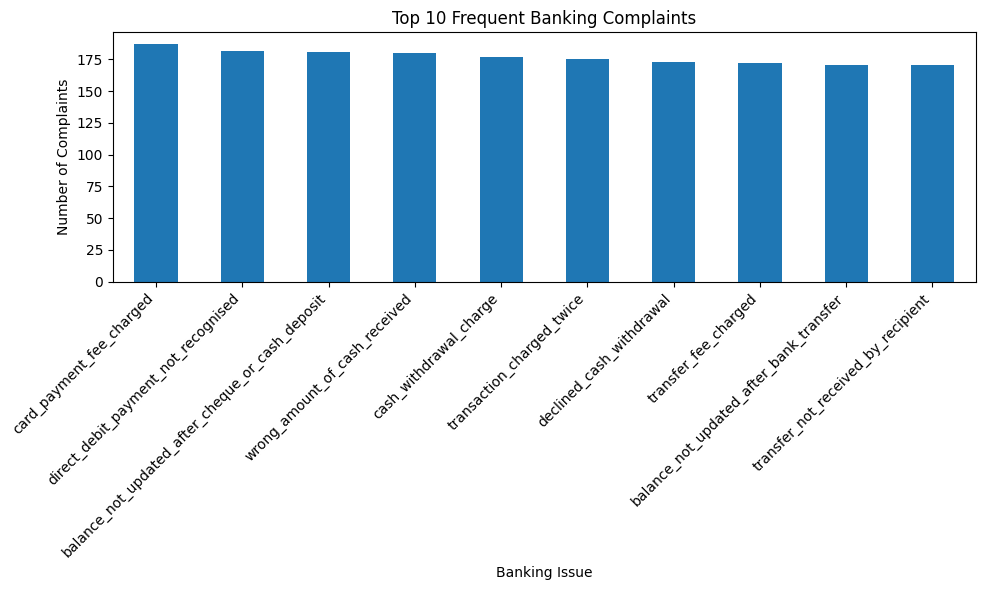

In [22]:
top_10 = category_counts.head(10)

plt.figure(figsize=(10, 6))

top_10.plot(kind='bar')

plt.title("Top 10 Frequent Banking Complaints")
plt.xlabel("Banking Issue")
plt.ylabel("Number of Complaints")

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [23]:
print("=" * 60)
print("       BANKING COMPLAINT ANALYTICAL REPORT")
print("=" * 60)

print("\nTotal Training Complaints:", len(train_df))
print("Total Testing Complaints :", len(test_df))

print(
    "Number of Complaint Categories:",
    train_df['category'].nunique()
)

print(
    "\nClassification Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

print("\nTOP 10 FREQUENT BANKING ISSUES")
print("-" * 60)

for i, (category, count) in enumerate(
        category_counts.head(10).items(), 1):

    print(
        f"{i}. {category} --> {count} complaints"
    )

       BANKING COMPLAINT ANALYTICAL REPORT

Total Training Complaints: 10003
Total Testing Complaints : 3080
Number of Complaint Categories: 77

Classification Accuracy: 83.28 %

TOP 10 FREQUENT BANKING ISSUES
------------------------------------------------------------
1. card_payment_fee_charged --> 187 complaints
2. direct_debit_payment_not_recognised --> 182 complaints
3. balance_not_updated_after_cheque_or_cash_deposit --> 181 complaints
4. wrong_amount_of_cash_received --> 180 complaints
5. cash_withdrawal_charge --> 177 complaints
6. transaction_charged_twice --> 175 complaints
7. declined_cash_withdrawal --> 173 complaints
8. transfer_fee_charged --> 172 complaints
9. balance_not_updated_after_bank_transfer --> 171 complaints
10. transfer_not_received_by_recipient --> 171 complaints
